# ⚖️ Comparaison des Algorithmes de Classification

Objectif : identifier le classifier naturellement le plus équitable sur les embeddings du meilleur modèle transformer.

In [1]:
# Cellule 1: Setup
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print('⚠️ XGBoost non installé — pip install xgboost')

if os.path.basename(os.getcwd()) != 'experiments':
    if os.path.exists(os.path.join(os.getcwd(), 'experiments')):
        os.chdir(os.path.join(os.getcwd(), 'experiments'))
print(f'📁 Répertoire: {os.getcwd()}')


⚠️ XGBoost non installé — pip install xgboost
📁 Répertoire: /Users/antoinedalle/Desktop/Period_3/Fair_AI/Projet/NLP_fairness_project/experiments


In [2]:
# Cellule 2: Charger données, embeddings, best RF params
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

def load_jsonl(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip(): data.append(json.loads(line))
    return data

df_train = pd.DataFrame(load_jsonl('medical_bios_data/train.jsonl'))
df_test  = pd.DataFrame(load_jsonl('medical_bios_data/test.jsonl'))
y_train  = le.transform(df_train['title'])
y_test   = le.transform(df_test['title'])
genders  = df_test['gender'].values

# Embeddings du meilleur modèle
try:
    with open('best_embedding_model.json') as f:
        best_info = json.load(f)
    model_id = best_info['model_id']
    print(f'📦 Embeddings: {best_info["label"]} ({model_id})')
except FileNotFoundError:
    model_id = 'distilroberta-base'
    print(f'⚠️ Utilisation de {model_id} par défaut')

safe_name = model_id.replace('/', '_')
CACHE_DIR = Path('embedding_cache')

train_cache = list(CACHE_DIR.glob(f'{safe_name}_{len(df_train)}*.npy'))
test_cache  = list(CACHE_DIR.glob(f'{safe_name}_{len(df_test)}*.npy'))

if not train_cache or not test_cache:
    raise FileNotFoundError('Embeddings non trouvés. Lancez d abord 03_embedding_models_comparison.ipynb')

emb_train = np.load(train_cache[0])
emb_test  = np.load(test_cache[0])

# Charger best RF params depuis notebook 04
try:
    with open('best_rf_params.json') as f:
        rf_params = json.load(f)
    print(f'📦 RF params: {rf_params}')
except FileNotFoundError:
    rf_params = {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 2}
    print(f'⚠️ Utilisation RF params par défaut: {rf_params}')

print(f'\n✅ Données prêtes — train: {emb_train.shape}, test: {emb_test.shape}')


📦 Embeddings: DistilRoBERTa (distilroberta-base)
📦 RF params: {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 10, 'accuracy': 0.899, 'mean_fairness_gap': 0.17270569811137712}

✅ Données prêtes — train: (8000, 768), test: (1000, 768)


In [3]:
# Cellule 3: Fonctions fairness
def compute_fairness_metrics(y_true, y_pred, genders, le):
    groups = np.unique(genders)
    metrics = {'accuracy': accuracy_score(y_true, y_pred)}
    for g in groups:
        mask = genders == g
        metrics[f'accuracy_{g.lower()}'] = accuracy_score(y_true[mask], y_pred[mask])
    dp_gaps, eo_gaps, eqodds_gaps = [], [], []
    for class_id in range(len(le.classes_)):
        rates, tprs, fprs = {}, {}, {}
        for g in groups:
            mask = genders == g
            rates[g] = np.mean(y_pred[mask] == class_id)
            pm = mask & (y_true == class_id)
            nm = mask & (y_true != class_id)
            tprs[g] = np.mean(y_pred[pm] == class_id) if pm.sum() > 0 else 0
            fprs[g] = np.mean(y_pred[nm] == class_id) if nm.sum() > 0 else 0
        if len(groups) == 2:
            g0, g1 = groups[0], groups[1]
            dp_gaps.append(abs(rates[g0]-rates[g1]))
            eo_gaps.append(abs(tprs[g0]-tprs[g1]))
            eqodds_gaps.append(max(abs(tprs[g0]-tprs[g1]), abs(fprs[g0]-fprs[g1])))
    metrics['delta_dp']     = np.mean(dp_gaps)
    metrics['delta_eo']     = np.mean(eo_gaps)
    metrics['delta_eqodds'] = np.mean(eqodds_gaps)
    return metrics

print('✅ Fonctions fairness prêtes')


✅ Fonctions fairness prêtes


## 🏃 Comparaison des Classifiers

In [4]:
# Cellule 4: Définir et entraîner les classifiers
rf_p = {k: v for k, v in rf_params.items() if k in ['n_estimators', 'max_depth', 'min_samples_split']}

CLASSIFIERS = [
    ('Random Forest',       RandomForestClassifier(**rf_p, random_state=42, n_jobs=-1)),
    ('Logistic Regression', Pipeline([('scaler', StandardScaler()),
                                       ('clf', LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1))])),
    ('SVM (RBF)',           Pipeline([('scaler', StandardScaler()),
                                       ('clf', SVC(kernel='rbf', probability=False, random_state=42))])),
    ('MLP',                 Pipeline([('scaler', StandardScaler()),
                                       ('clf', MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300, random_state=42))])),
]

if HAS_XGBOOST:
    CLASSIFIERS.append(('XGBoost', XGBClassifier(n_estimators=100, max_depth=6, random_state=42,
                                                   eval_metric='mlogloss', verbosity=0)))

results = []

for clf_name, clf in CLASSIFIERS:
    print(f'\n🔄 {clf_name}...')
    clf.fit(emb_train, y_train)
    preds = clf.predict(emb_test)

    fm = compute_fairness_metrics(y_test, preds, genders, le)
    fm['classifier'] = clf_name
    results.append(fm)

    print(f"  Accuracy: {fm['accuracy']:.4f} | ∆DP: {fm['delta_dp']:.4f} | ∆EO: {fm['delta_eo']:.4f}")

results_df = pd.DataFrame(results).set_index('classifier')
print('\n✅ Comparaison terminée')



🔄 Random Forest...
  Accuracy: 0.8990 | ∆DP: 0.1741 | ∆EO: 0.1720

🔄 Logistic Regression...


/Users/antoinedalle/Desktop/Period_3/Fair_AI/Projet/NLP_fairness_project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  Accuracy: 0.9680 | ∆DP: 0.1634 | ∆EO: 0.0346

🔄 SVM (RBF)...
  Accuracy: 0.9690 | ∆DP: 0.1676 | ∆EO: 0.0555

🔄 MLP...
  Accuracy: 0.9740 | ∆DP: 0.1632 | ∆EO: 0.0421

✅ Comparaison terminée


## 📊 Analyse Comparative

📊 TABLEAU COMPARATIF:
                     accuracy  accuracy_female  accuracy_male  delta_dp  delta_eo  delta_eqodds  mean_gap
classifier                                                                                               
Random Forest           0.899           0.8963         0.9022    0.1741    0.1720        0.1720    0.1727
Logistic Regression     0.968           0.9778         0.9565    0.1634    0.0346        0.0355    0.0778
SVM (RBF)               0.969           0.9759         0.9609    0.1676    0.0555        0.0555    0.0929
MLP                     0.974           0.9815         0.9652    0.1632    0.0421        0.0421    0.0824

🏆 Meilleur compromis: MLP
⚖️  Plus équitable: Logistic Regression


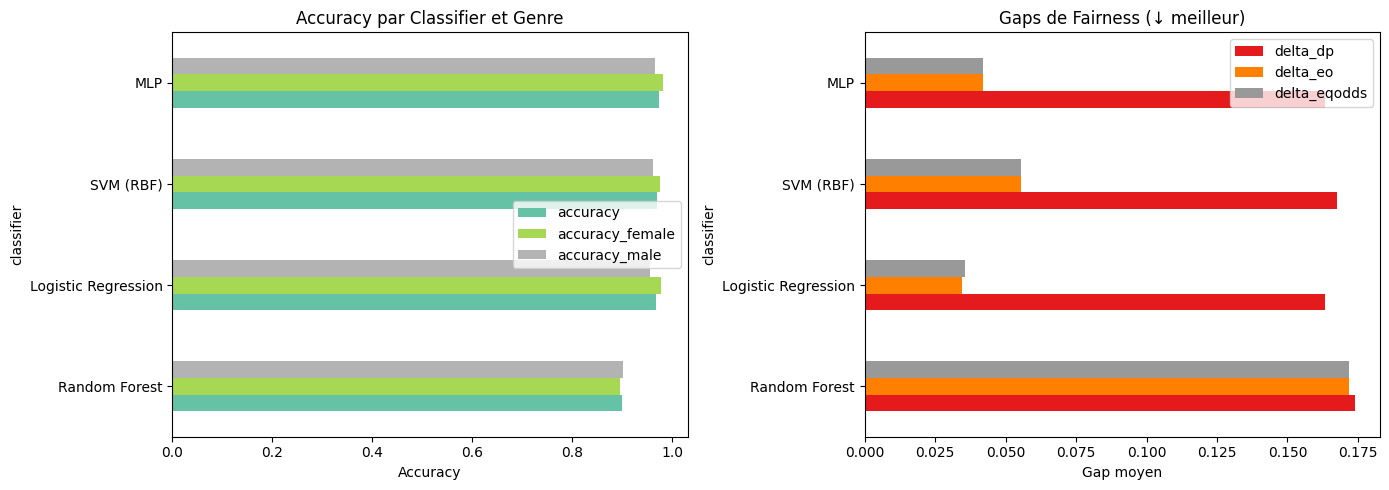

In [5]:
# Cellule 5: Tableau et visualisations
fairness_cols = ['delta_dp', 'delta_eo', 'delta_eqodds']
results_df['mean_gap'] = results_df[fairness_cols].mean(axis=1)
results_df['composite_score'] = results_df['accuracy'] - results_df['mean_gap']

display_cols = ['accuracy', 'accuracy_female', 'accuracy_male', 'delta_dp', 'delta_eo', 'delta_eqodds', 'mean_gap']
print('📊 TABLEAU COMPARATIF:')
print(results_df[display_cols].round(4).to_string())

best_clf = results_df['composite_score'].idxmax()
most_fair = results_df['mean_gap'].idxmin()
print(f'\n🏆 Meilleur compromis: {best_clf}')
print(f'⚖️  Plus équitable: {most_fair}')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
results_df[['accuracy', 'accuracy_female', 'accuracy_male']].plot(
    kind='barh', ax=axes[0], colormap='Set2')
axes[0].set_title('Accuracy par Classifier et Genre')
axes[0].set_xlabel('Accuracy')

# Fairness gaps
results_df[fairness_cols].plot(
    kind='barh', ax=axes[1], colormap='Set1')
axes[1].set_title('Gaps de Fairness (↓ meilleur)')
axes[1].set_xlabel('Gap moyen')

plt.tight_layout()
plt.savefig('classifier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# Cellule 6: Heatmap des gaps par classifier × profession
print('\n🔍 ANALYSE DÉTAILLÉE PAR PROFESSION:')

# Pour chaque classifier, calculer le gap ∆EO par profession
for clf_name, clf in CLASSIFIERS:
    preds = clf.predict(emb_test)
    print(f'\n--- {clf_name} ---')
    for class_id, prof in enumerate(le.classes_):
        tprs = {}
        for g in ['Female', 'Male']:
            mask = (genders == g) & (y_test == class_id)
            tprs[g] = np.mean(preds[mask] == class_id) if mask.sum() > 0 else float('nan')
        gap = abs(tprs.get('Female', 0) - tprs.get('Male', 0))
        flag = '🚨' if gap > 0.1 else '✅'
        print(f'  {flag} {prof}: ∆EO={gap:.3f} (F={tprs.get("Female",float("nan")):.3f}, M={tprs.get("Male",float("nan")):.3f})')



🔍 ANALYSE DÉTAILLÉE PAR PROFESSION:

--- Random Forest ---
  ✅ dentist: ∆EO=0.036 (F=0.910, M=0.946)
  🚨 nurse: ∆EO=0.350 (F=0.950, M=0.600)
  ✅ physician: ∆EO=0.023 (F=0.722, M=0.699)
  ✅ psychologist: ∆EO=0.006 (F=0.994, M=1.000)
  🚨 surgeon: ∆EO=0.445 (F=0.480, M=0.925)

--- Logistic Regression ---
  ✅ dentist: ∆EO=0.030 (F=0.970, M=1.000)
  ✅ nurse: ∆EO=0.044 (F=0.978, M=0.933)
  ✅ physician: ∆EO=0.027 (F=0.959, M=0.932)
  ✅ psychologist: ∆EO=0.059 (F=0.994, M=0.935)
  ✅ surgeon: ∆EO=0.012 (F=0.960, M=0.948)

--- SVM (RBF) ---
  ✅ dentist: ∆EO=0.030 (F=0.970, M=1.000)
  ✅ nurse: ∆EO=0.056 (F=0.989, M=0.933)
  ✅ physician: ∆EO=0.041 (F=0.959, M=0.918)
  ✅ psychologist: ∆EO=0.019 (F=1.000, M=0.981)
  🚨 surgeon: ∆EO=0.133 (F=0.800, M=0.933)

--- MLP ---
  ✅ dentist: ∆EO=0.015 (F=0.985, M=1.000)
  ✅ nurse: ∆EO=0.050 (F=0.983, M=0.933)
  ✅ physician: ∆EO=0.024 (F=0.969, M=0.945)
  ✅ psychologist: ∆EO=0.046 (F=1.000, M=0.954)
  ✅ surgeon: ∆EO=0.075 (F=0.880, M=0.955)


In [7]:
# Cellule 7: Sauvegarder résultats
results_df.to_csv('classifier_comparison_results.csv')

summary = {
    'best_tradeoff': best_clf,
    'most_fair':     most_fair,
    'best_accuracy': results_df['accuracy'].idxmax(),
    'scores': results_df[display_cols + ['composite_score']].round(4).to_dict()
}
with open('classifier_comparison_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('💾 classifier_comparison_results.csv')
print('💾 classifier_comparison_summary.json')
print('\n🎉 Phase 2 terminée!')
print('\n🎯 RECOMMANDATIONS POUR PHASE 3:')
print(f'  Utiliser {best_clf} avec embeddings {model_id}')
print('  → Notebooks 06-08: analyse approfondie de fairness')


💾 classifier_comparison_results.csv
💾 classifier_comparison_summary.json

🎉 Phase 2 terminée!

🎯 RECOMMANDATIONS POUR PHASE 3:
  Utiliser MLP avec embeddings distilroberta-base
  → Notebooks 06-08: analyse approfondie de fairness
